# Nuevo integrador 

**Fecha:** 2026-03-24


In [1]:
!pip install -Uq relatipy==0.3.6

In [2]:
import relatipy.numeric as rn
import relatipy.visualization as vis
import numpy as np
import matplotlib.pyplot as plt

In [3]:
kerr = rn.metrics.Kerr(a=0.5, mass=1)

In [4]:
isco_prograde = kerr.isco_prograde
isco_retrograde = kerr.isco_retrograde
R_s = kerr.R_s

In [6]:
ics = rn.coordinates.OrbitalElements(
    t=0,
    a=5*isco_prograde,
    e=0,
    inc=0,
    Omega=0,
    omega=0,
    f=0,
    mass=1
)
P = ics._get_period()
print(P)

611.7974561486187


In [7]:
taus = (0, 500*P)
path = kerr.geodesic.get_path(ics, taus, integrator="Radau2")
from relatipy.visualization._3D.plot_black_hole import PlotKerr
plot = PlotKerr(kerr)
plot.add_path(path, label="orbit")
plot.plot().show()

# # save ../figures/003-integradores_a_largo_plazo/orbit.png as plotly html
# plot.plot().write_html("../figures/003-integradores_a_largo_plazo/orbit.html")


In [ ]:
from relatipy.visualization._2D import SciSubplot

# Misma configuración que en 003: a = 100*R_s, inclinaciones 0°…90°,
# ventana temporal 500 períodos de la órbita de referencia (inc=10).
ics_ref = rn.coordinates.OrbitalElements(
    t=0,
    a=100 * R_s,
    e=0,
    inc=10,
    Omega=0,
    omega=0,
    f=0,
    mass=1,
)
P_ref = ics_ref._get_period()
taus = (0, 500 * P_ref)

N = 10

ics_ = [
    rn.coordinates.OrbitalElements(
        t=0,
        a=100 * R_s,
        e=0,
        inc=inc,
        Omega=0,
        omega=0,
        f=0,
        mass=1,
    )
    for inc in [(40/N) * i for i in range(0, N+1)]
]
Ps = [ics_i._get_period() for ics_i in ics_]
paths = [
    kerr.geodesic.get_path(ics_i, taus, integrator="Yoshida6").convert_to(
        "BoyerLindquist", a=kerr.a
    )
    for ics_i in ics_
]


def plot_errors(workspace, path, P, taus, label=""):
    fig, axs = workspace.fig, workspace.axs

    muestreo = 1000

    times = path[0][::muestreo] / P
    get_absolute_error = lambda x: abs((x - x[0]) / x[0]) * 100

    labels = [
        {"values": lambda p: p._get_Q(kerr)[::muestreo], "ax": 0, "ylabel": r"Relative error in $Q$ (%)"},
        {"values": lambda p: p._get_E(kerr)[::muestreo], "ax": 1, "ylabel": r"Relative error in $E$ (%)"},
        {"values": lambda p: p._get_Lz(kerr)[::muestreo], "ax": 2, "ylabel": r"Relative error in $L_z$ (%)"},
    ]
    for i, l in enumerate(labels):
        values = l["values"](path)
        errors = get_absolute_error(values)

        axs[i].plot(times, errors, ".", label=label if i == 0 else "")

        axs[i].set_xlim(taus[0] / P, taus[1] / P)
        axs[i].set_ylabel(l["ylabel"])
        if i == 2:
            axs[i].set_xlabel("Time (periods)")

    axs[0].set_xticklabels([])
    axs[1].set_xticklabels([])
    fig.subplots_adjust(hspace=0)


workspace = SciSubplot(figsize=(5, 6), subplot=(3, 1))
fig, axs = workspace.fig, workspace.axs

for i, path in enumerate(paths[:-1]):
    plot_errors(workspace, path, Ps[i], taus, f"inc={ics_[i].inc}")

handles, labels_ = axs[0].get_legend_handles_labels()
unique = dict(zip(labels_, handles))
fig.legend(
    unique.values(),
    unique.keys(),
    loc="center left",
    bbox_to_anchor=(0.70, 0.5),
    frameon=False,
    borderaxespad=0,
    labelspacing=0.5,
    handletextpad=0.1,
    ncol=1,
    fontsize="medium",
)
fig.subplots_adjust(right=0.7)

import os

# os.makedirs("../figures/004-nuevo_integrador", exist_ok=True)
# fig.savefig("../figures/004-nuevo_integrador/errors_Q_E_Lz_Yoshida6_sin_projection.png")


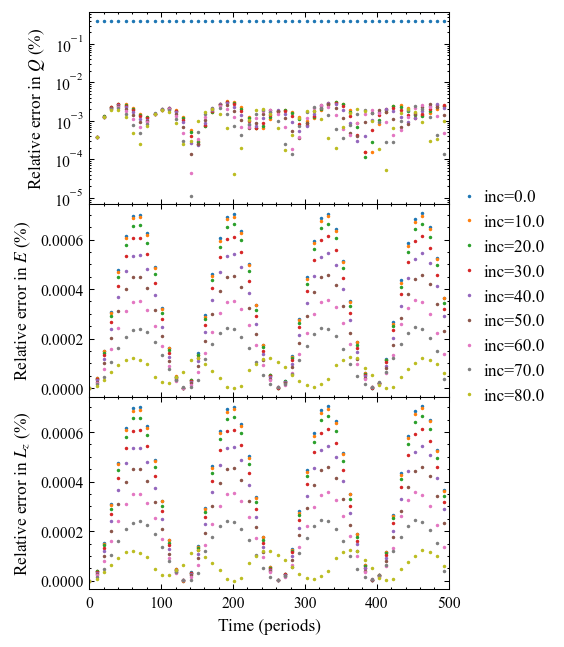

In [ ]:
from relatipy.visualization._2D import SciSubplot

# Misma configuración que en 003: a = 100*R_s, inclinaciones 0°…90°,
# ventana temporal 500 períodos de la órbita de referencia (inc=10).
ics_ref = rn.coordinates.OrbitalElements(
    t=0,
    a=100 * R_s,
    e=0,
    inc=10,
    Omega=0,
    omega=0,
    f=0,
    mass=1,
)
P_ref = ics_ref._get_period()
taus = (0, 500 * P_ref)

N = 9

ics_ = [
    rn.coordinates.OrbitalElements(
        t=0,
        a=100 * R_s,
        e=0,
        inc=inc,
        Omega=0,
        omega=0,
        f=0,
        mass=1,
    )
    for inc in [(90/N) * (i) for i in range(0, N+1)]
]
Ps = [ics_i._get_period() for ics_i in ics_]
paths = [
    kerr.geodesic.get_path(ics_i, taus, integrator="Radau2").convert_to(
        "BoyerLindquist", a=kerr.a
    )
    for ics_i in ics_
]


def plot_errors(workspace, path, P, taus, label=""):
    fig, axs = workspace.fig, workspace.axs

    muestreo = 1000

    times = path[0][::muestreo] / P
    get_absolute_error = lambda x: abs((x - x[0]) / x[0]) * 100

    labels = [
        {"values": lambda p: p._get_Q(kerr)[::muestreo], "ax": 0, "ylabel": r"Relative error in $Q$ (%)"},
        {"values": lambda p: p._get_E(kerr)[::muestreo], "ax": 1, "ylabel": r"Relative error in $E$ (%)"},
        {"values": lambda p: p._get_Lz(kerr)[::muestreo], "ax": 2, "ylabel": r"Relative error in $L_z$ (%)"},
    ]
    for i, l in enumerate(labels):
        values = l["values"](path)
        errors = get_absolute_error(values)

        axs[i].plot(times, errors, ".", label=label if i == 0 else "", markersize=2)

        axs[i].set_xlim(taus[0] / P, taus[1] / P)
        axs[i].set_ylabel(l["ylabel"])
        if i == 2:
            axs[i].set_xlabel("Time (periods)")

    axs[0].set_xticklabels([])
    axs[1].set_xticklabels([])
    fig.subplots_adjust(hspace=0)


workspace = SciSubplot(figsize=(5, 6), subplot=(3, 1))
fig, axs = workspace.fig, workspace.axs

for i, path in enumerate(paths[:-1]):
    plot_errors(workspace, path, Ps[i], taus, f"inc={ics_[i].inc}")

handles, labels_ = axs[0].get_legend_handles_labels()
unique = dict(zip(labels_, handles))
fig.legend(
    unique.values(),
    unique.keys(),
    loc="center left",
    bbox_to_anchor=(0.70, 0.5),
    frameon=False,
    borderaxespad=0,
    labelspacing=0.5,
    handletextpad=0.1,
    ncol=1,
    fontsize="medium",
)
fig.subplots_adjust(right=0.7)

axs[0].set_yscale("log")
# axs[1].set_yscale("log")
# axs[2].set_yscale("log")

import os

# os.makedirs("../figures/004-nuevo_integrador", exist_ok=True)
# fig.savefig("../figures/004-nuevo_integrador/errors_Q_E_Lz_Radau2_con_projection.png")
